#1 Load libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [37]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [38]:
#load the data
df = pd.read_csv('../data/telco_customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.shape

(7043, 21)

Basic Info

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [41]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
print('Target value distribution')
df['Churn'].value_counts()

Target value distribution


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [43]:
print(f'Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')
print(f'Non-churn rate: {df["Churn"].value_counts(normalize=True)["No"]*100:.1f}%')

Churn rate: 26.5%
Non-churn rate: 73.5%


Analysis numerical features

In [44]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [45]:
df[numerical_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Visualize target variable

<Axes: xlabel='Churn', ylabel='count'>

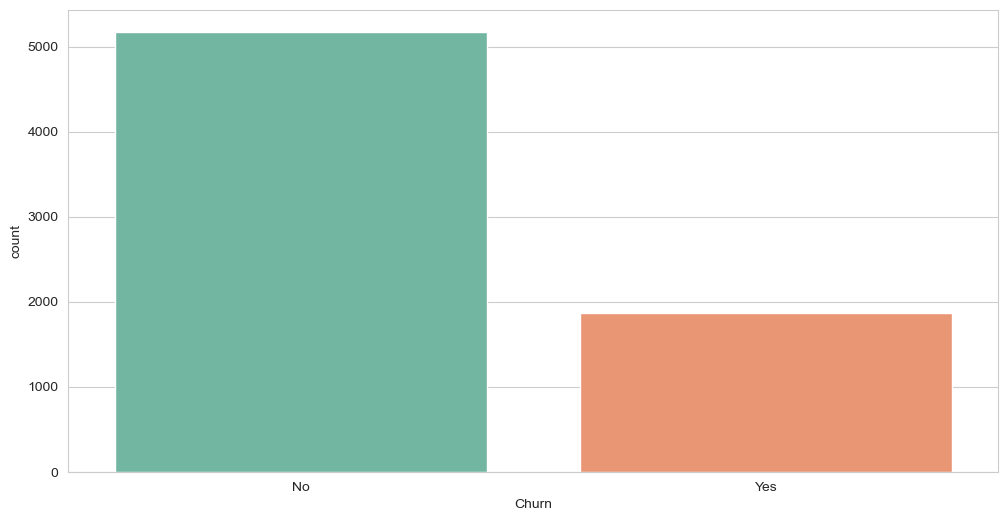

In [46]:
sns.countplot(data=df, x='Churn', palette='Set2')

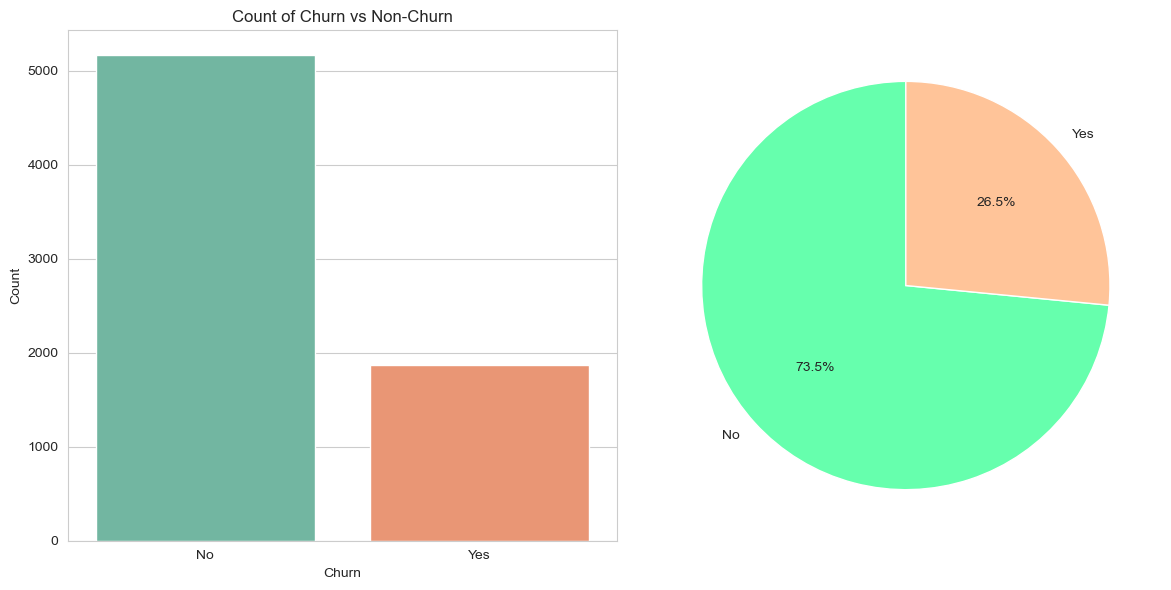

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(data=df, x='Churn', ax=ax[0], palette='Set2')
ax[0].set_title('Count of Churn vs Non-Churn')
ax[0].set_ylabel('Count')

ax[1].pie(df['Churn'].value_counts(), labels=df['Churn'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=["#66ffad","#ffc499"])

plt.tight_layout()

plt.savefig('../reports/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Numerical features v/s churn

In [48]:
df.drop(['Totalcharges'], axis=1, inplace=True)

KeyError: "['Totalcharges'] not found in axis"

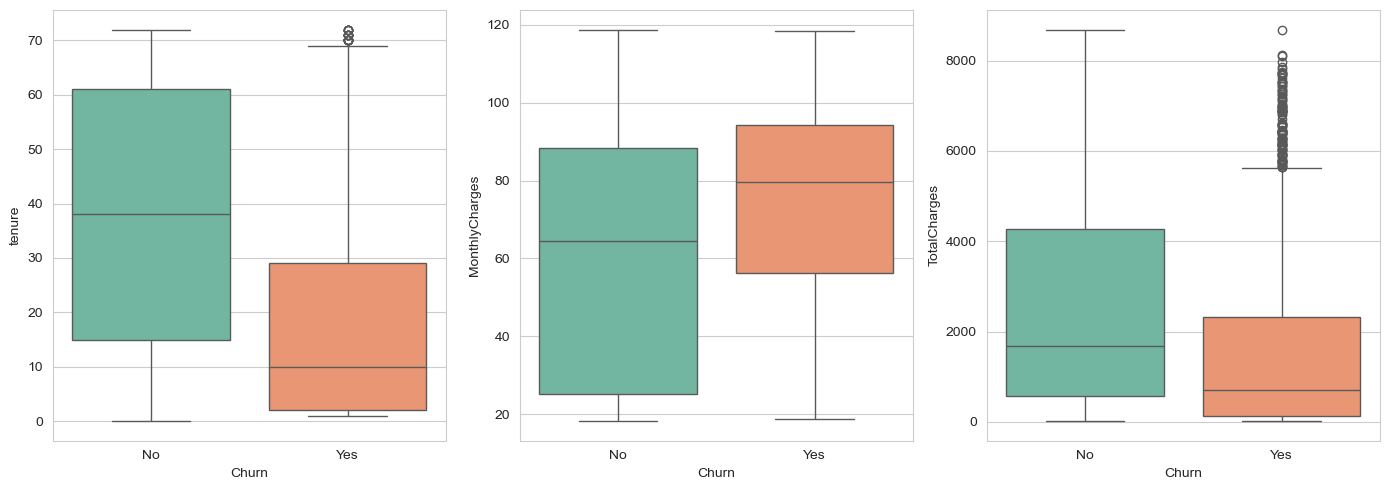

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=ax[0], palette='Set2')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax[1], palette='Set2')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax[2], palette='Set2')

plt.tight_layout()
plt.savefig('../reports/numerical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object


Analyze categorical features

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [57]:
categorical_cols.remove('Churn')
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [58]:
print(f"categorical columns {len(categorical_cols)}: {categorical_cols}")

categorical columns 15: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


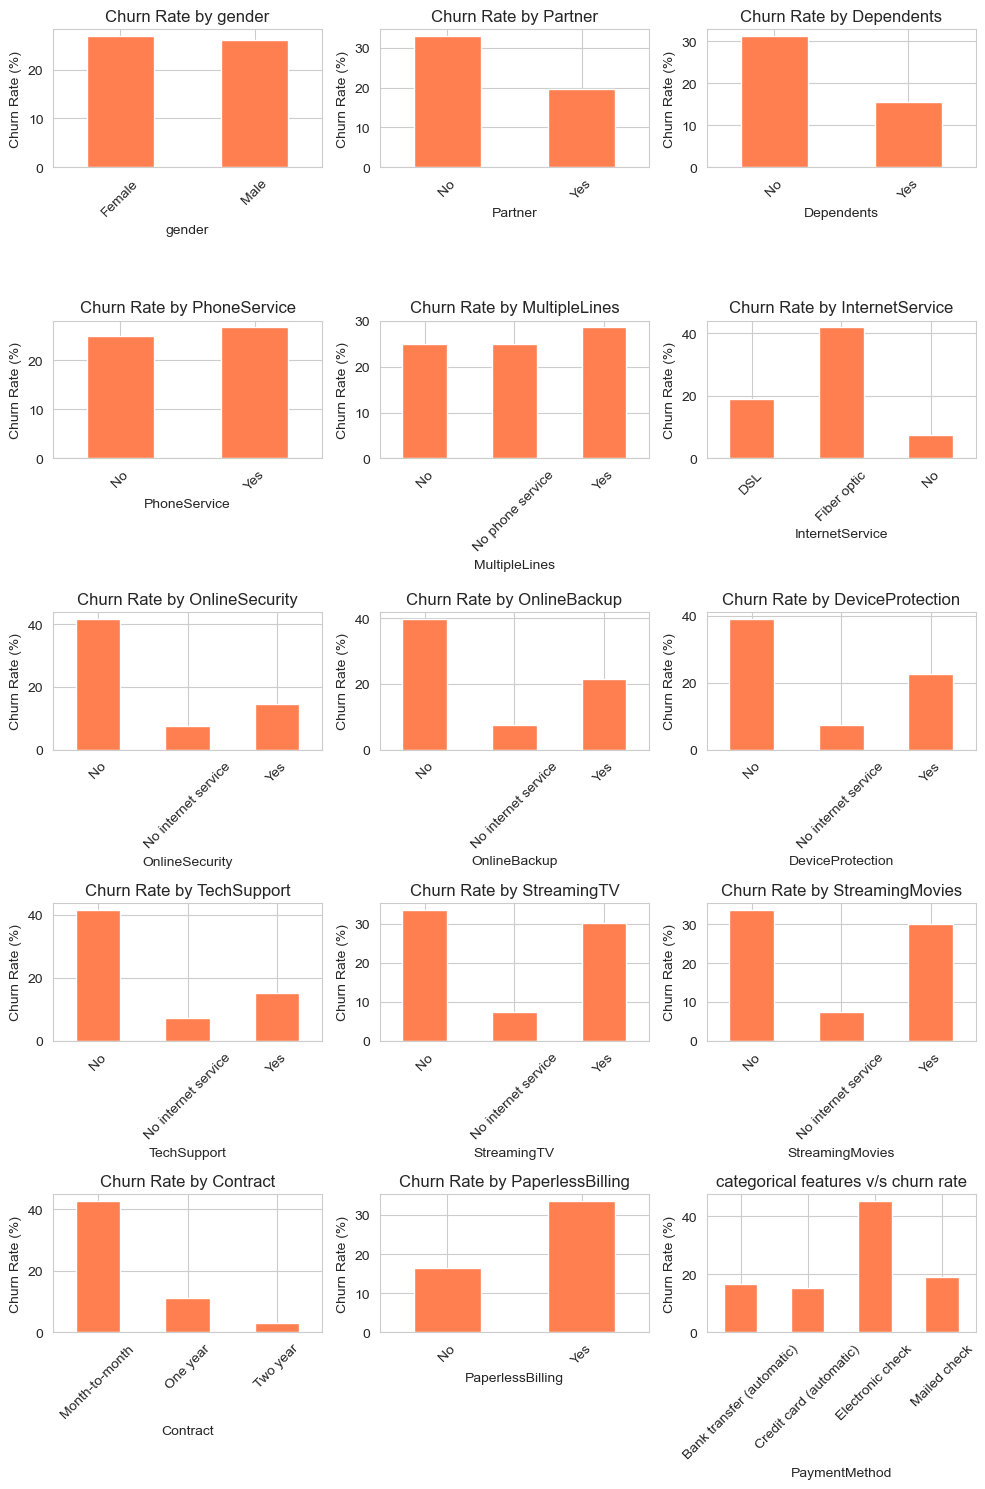

In [59]:
fig, ax = plt.subplots(5, 3, figsize = (10,15))
ax = ax.flatten()

for idx, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').sum()/len(x)*100)
    churn_rate.plot(kind='bar', ax=ax[idx], color='coral')
    ax[idx].set_title(f'Churn Rate by {col}')
    ax[idx].set_ylabel('Churn Rate (%)')
    ax[idx].set_xlabel(col)
    ax[idx].tick_params(axis='x', rotation=45)

plt.title('categorical features v/s churn rate')
plt.tight_layout()
plt.savefig('../reports/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

In [62]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

In [63]:
corr_matrix = df_corr[numerical_features].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


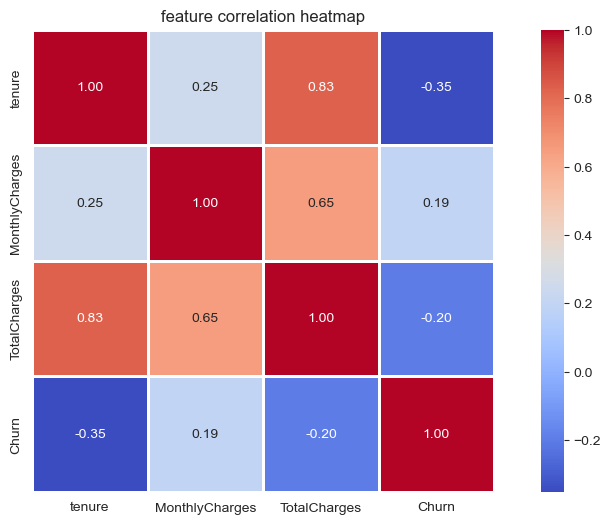

In [64]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True, fmt=".2f", linewidths=1)
plt.title('feature correlation heatmap')
plt.savefig('../reports/correlation_heatmap.png', dpi=300, bbox_inches='tight')

In [65]:
df_corr.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


NOTE: A multicolinearity between 'tenure and totalcharges'

In [71]:
print(f'\n1. Dataset size: {df.shape[0]} customers and {df.shape[1]} features')
print(f'\n2. Churn rate: {(df["Churn"]=="Yes").sum()/len(df)*100:.2f}%')
print(f'\n3. Missing values: {df.isnull().sum().sum()} total')

avg_tenure_churn = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_no_churn = df[df['Churn'] == 'No']['tenure'].mean()

print(f'\n4. Average tenure of churned customers: {avg_tenure_churn:.2f} months')
print(f'\n5. Average tenure of non-churned customers: {avg_tenure_no_churn:.2f} months')

avg_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_no_churn = df[df['Churn'] == 'No']['MonthlyCharges'].mean()

print(f'\n6. Average monthly charges of churned customers: ${avg_monthly_churn:.2f}')
print(f'\n7. Average monthly charges of non-churned customers: ${avg_monthly_no_churn:.2f}')

print(f'\n8. Average total charges of churned customers: ${df[df["Churn"] == "Yes"]["TotalCharges"].mean():.2f}')
print(f'\n9. Average total charges of non-churned customers: ${df[df["Churn"] == "No"]["TotalCharges"].mean():.2f}')

print(f'\n10. Most common contract type among churned customers: {df[df["Churn"] == "Yes"]["Contract"].mode()[0]}')


1. Dataset size: 7043 customers and 21 features

2. Churn rate: 26.54%

3. Missing values: 11 total

4. Average tenure of churned customers: 17.98 months

5. Average tenure of non-churned customers: 37.57 months

6. Average monthly charges of churned customers: $74.44

7. Average monthly charges of non-churned customers: $61.27

8. Average total charges of churned customers: $1531.80

9. Average total charges of non-churned customers: $2555.34

10. Most common contract type among churned customers: Month-to-month
